<a href="https://colab.research.google.com/github/stacykeago/Tata-Motors-Stock-Price-Prediction-Random-forest-regression-K-Nearest-Neighbour/blob/main/Tata_Motors_Stock_Price_Prediction_using_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Define the question
There has been an increase of more than 10 per cent in the stock price of Tata Motors. This has resulted in more attention to Tata Group stocks from all over India. But again today, we are witnessing a fall in the prices of Tata Motors’ shares, which can be a negative signal for investors.  we want to learn how to analyze and predict the Tata Motors stock price

2. Metric for success
Making correct predictions on Tata Motors stock price with the model with the lowest mean squared error or the model with highest accuracy.

3. Experimental design taken
Import libraries
Load  dataset
clean the data
Exploratory data analysis techniques

4. Appropriateness of available data to answer the given question. To get the data:
        *   Visit Yahoo Finance
        *   Search for Tata Motors or TTM (it’s the stock symbol of Tata Motors)
        *   Then click on Historical data and click on download.         


# DATA CLEANING

## Import libraries

In [13]:
# Import libraries
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import matplotlib.pyplot as plt  # for data visualization
import seaborn as sns            # for statistical data visualization
%matplotlib inline

## Load Datasets

In [17]:
import yfinance as yf

# Use a single valid ticker that won't throw missing data errors
ttm = yf.download("TMPV.NS", start="2023-01-01")

# Clean up columns and view data
ttm.columns = ttm.columns.get_level_values(0) if isinstance(ttm.columns, tuple) else ttm.columns
ttm = ttm.reset_index()
ttm.head()

/tmp/ipykernel_1377/4034506865.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ttm = yf.download("TMPV.NS", start="2023-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,TMPV.NS,TMPV.NS,TMPV.NS,TMPV.NS,TMPV.NS
0,2023-01-02,384.626770,385.795860,380.924700,382.386048,10501357
1,2023-01-03,383.749939,388.085283,382.873136,385.795832,9431220
2,2023-01-04,375.663818,384.626734,375.079273,384.626734,16121049
3,2023-01-05,376.930328,378.732663,372.643714,377.904560,10443908
4,2023-01-06,372.156586,378.391664,371.182354,376.150942,8715469


## Data shape

In [18]:
# Rows and columns
ttm.shape

(930, 6)

### Column list

In [19]:
ttm.columns

MultiIndex([(  'Date',        ''),
            ( 'Close', 'TMPV.NS'),
            (  'High', 'TMPV.NS'),
            (   'Low', 'TMPV.NS'),
            (  'Open', 'TMPV.NS'),
            ('Volume', 'TMPV.NS')],
           names=['Price', 'Ticker'])

## Dataset summary info

In [20]:
#Check for dataset info
ttm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 930 entries, 0 to 929
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   (Date, )           930 non-null    datetime64[ns]
 1   (Close, TMPV.NS)   930 non-null    float64       
 2   (High, TMPV.NS)    930 non-null    float64       
 3   (Low, TMPV.NS)     930 non-null    float64       
 4   (Open, TMPV.NS)    930 non-null    float64       
 5   (Volume, TMPV.NS)  930 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 43.7 KB


- 224 . Representing time from Nov 12 2025 to s
-

### Check for unique

In [21]:
# Check for unique values in each column
ttm.nunique()

,,0
Price,Ticker,
Date,,930
Close,TMPV.NS,907
High,TMPV.NS,927
Low,TMPV.NS,928
Open,TMPV.NS,928
Volume,TMPV.NS,925


# Preprocessing data

###  Check for duplicates

In [22]:
ttm.duplicated().any()

np.False_

### Data types in each column

In [23]:
# Check for data types in each column
ttm.dtypes

,,0
Price,Ticker,
Date,,datetime64[ns]
Close,TMPV.NS,float64
High,TMPV.NS,float64
Low,TMPV.NS,float64
Open,TMPV.NS,float64
Volume,TMPV.NS,int64


#### # Convert Date column to data type " Date" format

In [24]:
ttm['Date'] = pd.to_datetime(ttm['Date'])
ttm.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,TMPV.NS,TMPV.NS,TMPV.NS,TMPV.NS,TMPV.NS
0,2023-01-02,384.626770,385.795860,380.924700,382.386048,10501357
1,2023-01-03,383.749939,388.085283,382.873136,385.795832,9431220
2,2023-01-04,375.663818,384.626734,375.079273,384.626734,16121049
3,2023-01-05,376.930328,378.732663,372.643714,377.904560,10443908
4,2023-01-06,372.156586,378.391664,371.182354,376.150942,8715469


### Check for null values

In [25]:
ttm.isnull().sum()

,,0
Price,Ticker,
Date,,0
Close,TMPV.NS,0
High,TMPV.NS,0
Low,TMPV.NS,0
Open,TMPV.NS,0
Volume,TMPV.NS,0


### Check for NA Values

In [26]:
print("NA values:", ttm.isna().values.any())

NA values: False


## Sorting dataset by date format

In [27]:
ttm.sort_values(by='Date', inplace=True)
ttm.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,TMPV.NS,TMPV.NS,TMPV.NS,TMPV.NS,TMPV.NS
0,2023-01-02,384.626770,385.795860,380.924700,382.386048,10501357
1,2023-01-03,383.749939,388.085283,382.873136,385.795832,9431220
2,2023-01-04,375.663818,384.626734,375.079273,384.626734,16121049
3,2023-01-05,376.930328,378.732663,372.643714,377.904560,10443908
4,2023-01-06,372.156586,378.391664,371.182354,376.150942,8715469


### Outliers

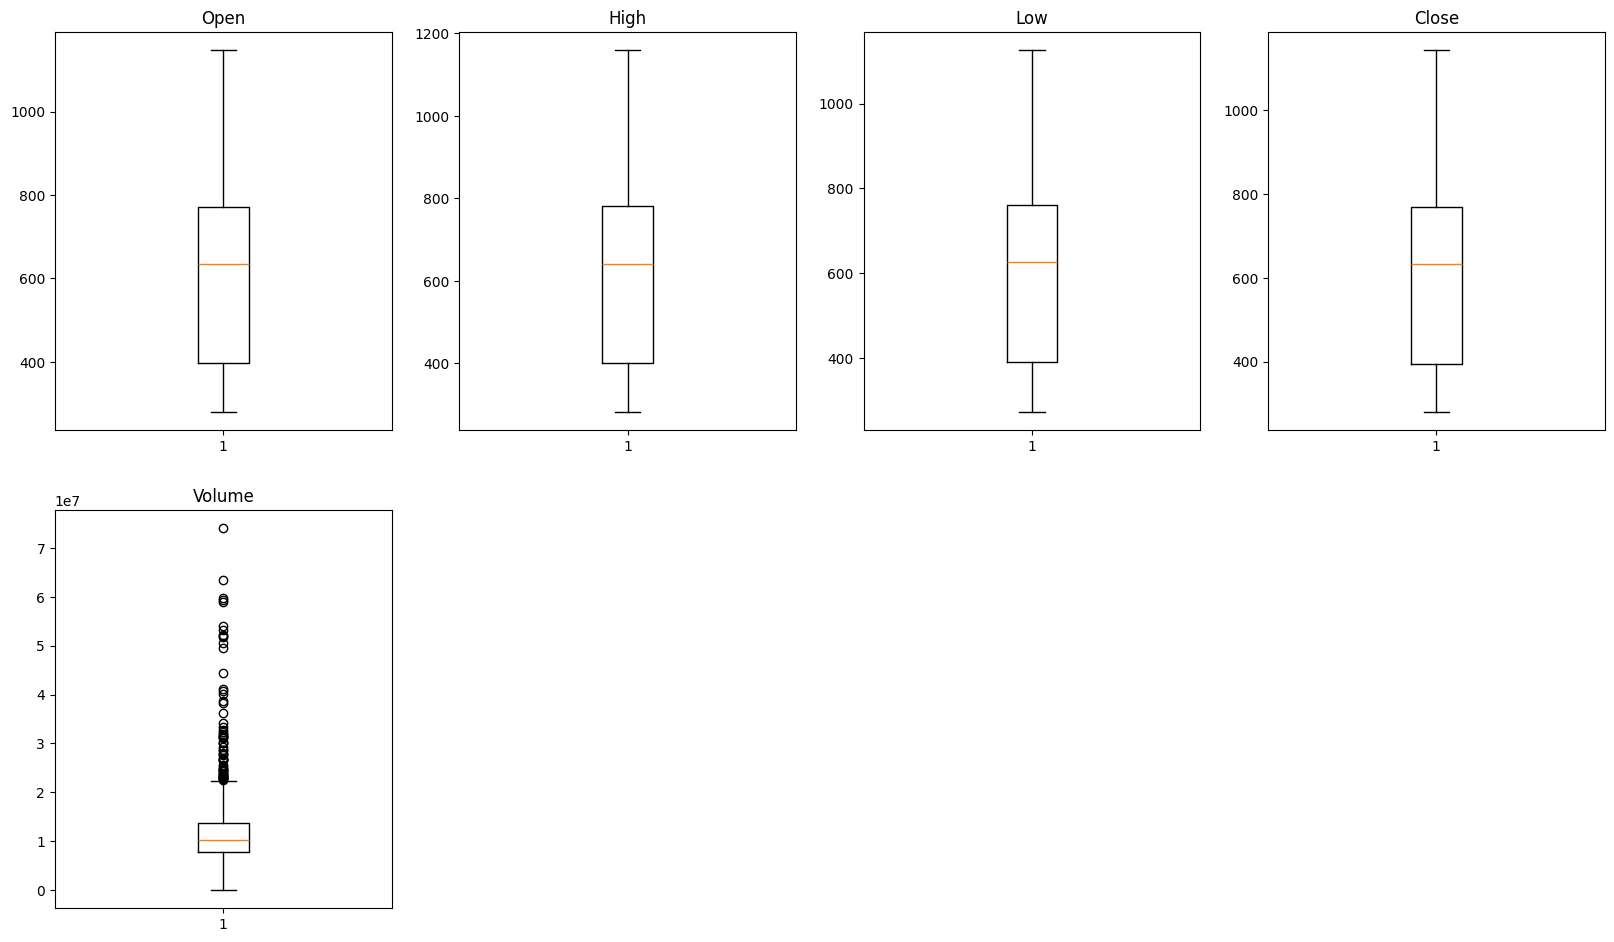

In [29]:
columns_dict ={ 'Open':1, 'High':2, 'Low':3, 'Close':4, 'Volume':5}
plt.figure(figsize=(20,30))

# make a boxplot for each numerical column
for variable,i in columns_dict.items():
  plt.subplot(5,4,i)
  plt.boxplot(ttm[variable])
  plt.title(variable)

plt.show()

# EXPLORATORY DATA ANALYSIS

## Numeric Features Description

In [30]:
# Count, mean, standard deviation, minimum, maximum,
ttm.describe().T

,,count,mean,min,25%,50%,75%,max,std
Price,Ticker,,,,,,,,
Date,,930,2024-11-20 06:11:36.774193408,2023-01-02 00:00:00,2023-12-12 06:00:00,2024-11-23 12:00:00,2025-10-29 18:00:00,2026-10-01 00:00:00,NaN
Close,TMPV.NS,930.0,621.194078,279.399994,394.725639,633.142059,769.22551,1142.468628,225.892323
High,TMPV.NS,930.0,629.091767,281.299988,400.151057,641.984077,780.665358,1159.332565,228.95297
Low,TMPV.NS,930.0,614.216447,272.200012,390.18883,627.357379,760.872386,1126.194706,223.240611
Open,TMPV.NS,930.0,622.545379,279.0,396.561567,633.755131,771.376534,1147.532791,226.68689
Volume,TMPV.NS,930.0,12212525.755914,0.0,7836933.0,10351373.0,13754152.0,74052760.0,7729587.871385


## Monthwise comparision between Stock open and close price

In [38]:
# Flatten the MultiIndex columns properly
ttm.columns = [col[0] if isinstance(col, tuple) else col for col in ttm.columns]

#  monthly comparison
monthwise = ttm.groupby(ttm['Date'].dt.strftime('%B'))[['Open', 'Close']].mean()
new_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthwise = monthwise.reindex(new_order, axis=0)
monthwise

,Open,Close
Date,,
January,576.317108,576.250026
February,600.492473,598.606342
March,579.283398,578.394372
April,602.723867,602.884376
May,623.592732,623.312098
June,631.205832,629.717123
July,655.992350,656.281907
August,664.655314,661.953803
September,647.642438,644.727286


### Plot Monthwise comparision between Stock open and close price

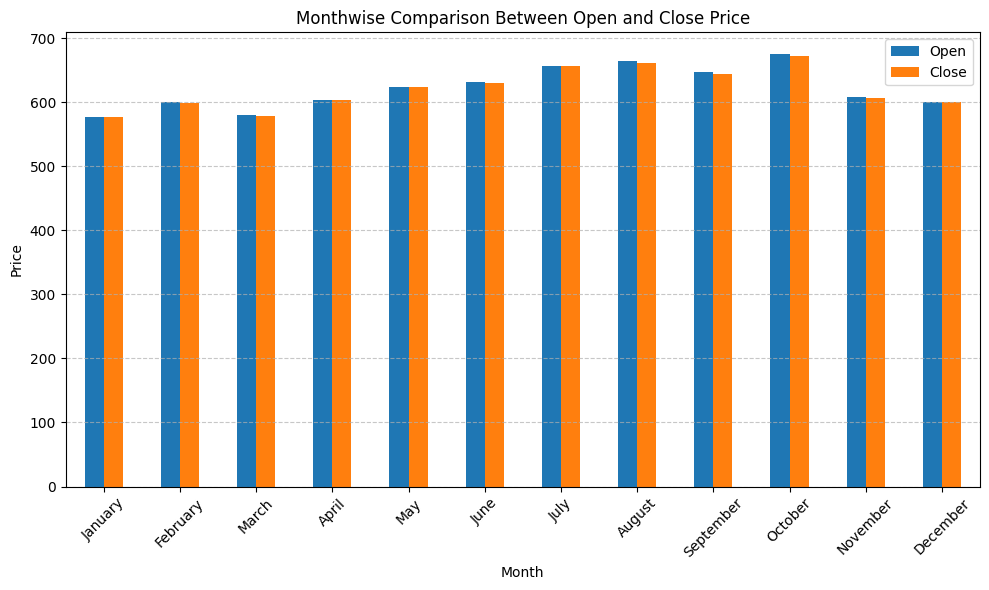

In [36]:
# Plot the monthly comparison data
monthwise.plot(kind='bar', figsize=(10, 6))
plt.title('Monthwise Comparison Between Open and Close Price')
plt.xlabel('Month')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(['Open', 'Close'])
plt.tight_layout()
plt.show()

## Monthwise High and Low stock price

In [42]:
# Monthwise High and Low stock price
monthwise_high_low = ttm.groupby(ttm['Date'].dt.strftime('%B'))[['High', 'Low']].agg({'High': 'max', 'Low': 'min'})
new_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthwise_high_low = monthwise_high_low.reindex(new_order, axis=0)
monthwise_high_low

,High,Low
Date,,
January,876.120973,332.838998
February,953.813766,338.293760
March,1041.377047,291.878760
April,1006.097707,292.622591
May,1026.473694,330.905026
June,993.397533,343.299988
July,1159.332565,318.250000
August,1156.382658,308.850006
September,1086.567056,272.200012


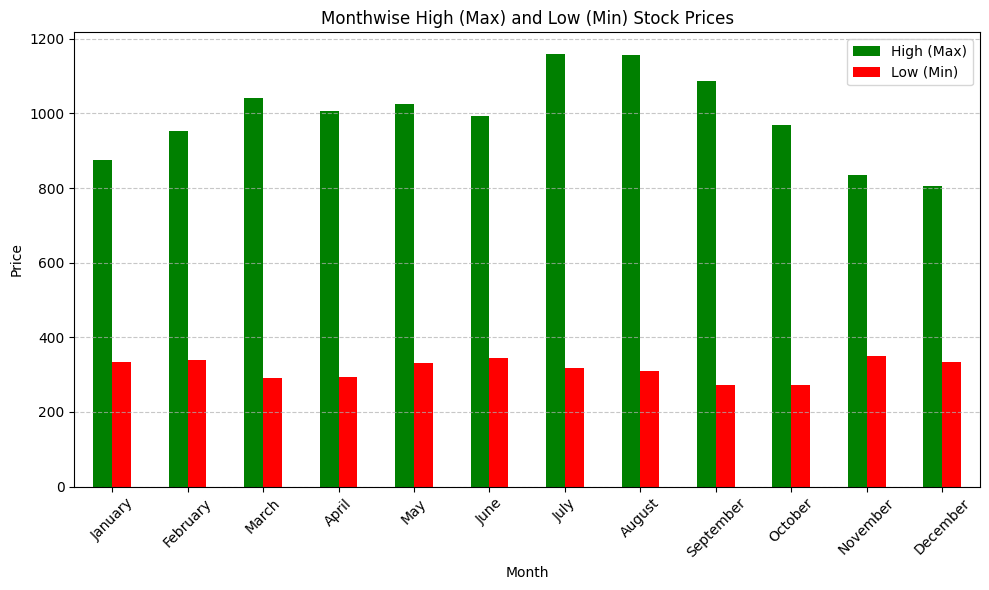

In [43]:
import matplotlib.pyplot as plt

# Plot Monthwise High and Low stock price
monthwise_high_low.plot(kind='bar', figsize=(10, 6), color=['green', 'red'])
plt.title('Monthwise High (Max) and Low (Min) Stock Prices')
plt.xlabel('Month')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(['High (Max)', 'Low (Min)'])
plt.tight_layout()
plt.show()

## Trend comparision between stock open price, close price, high price, low price

In [40]:
from itertools import cycle
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

In [41]:
from itertools import cycle

names = cycle(['Stock Open Price', 'Stock Close Price', 'Stock High Price', 'Stock Low Price'])

fig = px.line(ttm, x='Date', y=['Open', 'Close', 'High', 'Low'],
             labels={'Date': 'Date', 'value': 'Stock value'})
fig.update_layout(title_text='Stock analysis chart', font_size=15, font_color='black', legend_title_text='Stock Parameters')
fig.for_each_trace(lambda t: t.update(name=next(names)))
fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)

fig.show()

#### Plotting Stock Close price chart

In [44]:
import plotly.express as px

# Define closedf from your main dataframe
closedf = ttm[['Date', 'Close']].copy()

# Plotting Stock Close price chart
fig = px.line(closedf, x='Date', y='Close', labels={'Date': 'Date', 'Close': 'Close Stock'})
fig.update_traces(marker_line_width=2, opacity=0.8)
fig.update_layout(title_text='Stock close price chart', plot_bgcolor='white', font_size=15, font_color='black')
fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)
fig.show()

## Print the duration of the dataset

In [45]:
print("Starting date:", ttm['Date'].iloc[0])
print("Ending date:", ttm['Date'].iloc[-1])
print("Duration:", ttm['Date'].iloc[-1] - ttm['Date'].iloc[0])

Starting date: 2023-01-02 00:00:00
Ending date: 2026-10-01 00:00:00
Duration: 1368 days 00:00:00


## Consider the last 6 months

In [51]:
# Filter dynamically for the last 6 months
six_months_ago = closedf['Date'].max() - pd.DateOffset(months=6)
closedf = closedf[closedf['Date'] >= six_months_ago]
close_stock = closedf.copy()

print("Total data for prediction: ", closedf.shape[0])

fig = px.line(closedf, x='Date', y='Close', labels={'Date': 'Date', 'Close': 'Close Stock'})
fig.update_traces(marker_line_width=2, opacity=0.8, marker_line_color='orange')
fig.update_layout(
    title_text='Last 6 months period to predict Stock close price',
    plot_bgcolor='white',
    font_size=15,
    font_color='black',
    margin=dict(l=60, r=20, t=60, b=50),
    xaxis_title='Date',
    yaxis_title='Close Stock'
)
fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)
fig.show()


Total data for prediction:  130


# UNIVARIATE ANALYSIS

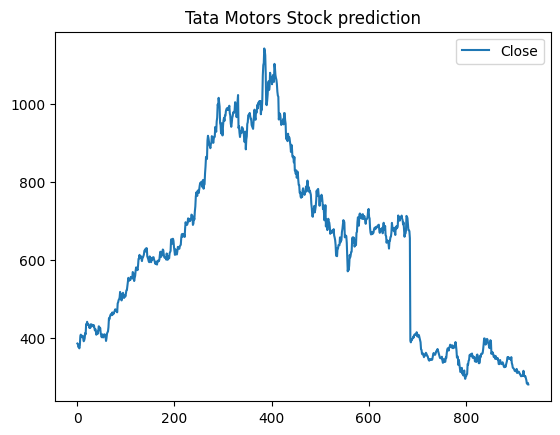

In [52]:
ttm[['Close']].plot()
plt.title("Tata Motors Stock prediction")
plt.show()

In [53]:
from matplotlib.axes._axes import _log as matplotlib_axes_logger
matplotlib_axes_logger.setLevel('ERROR')

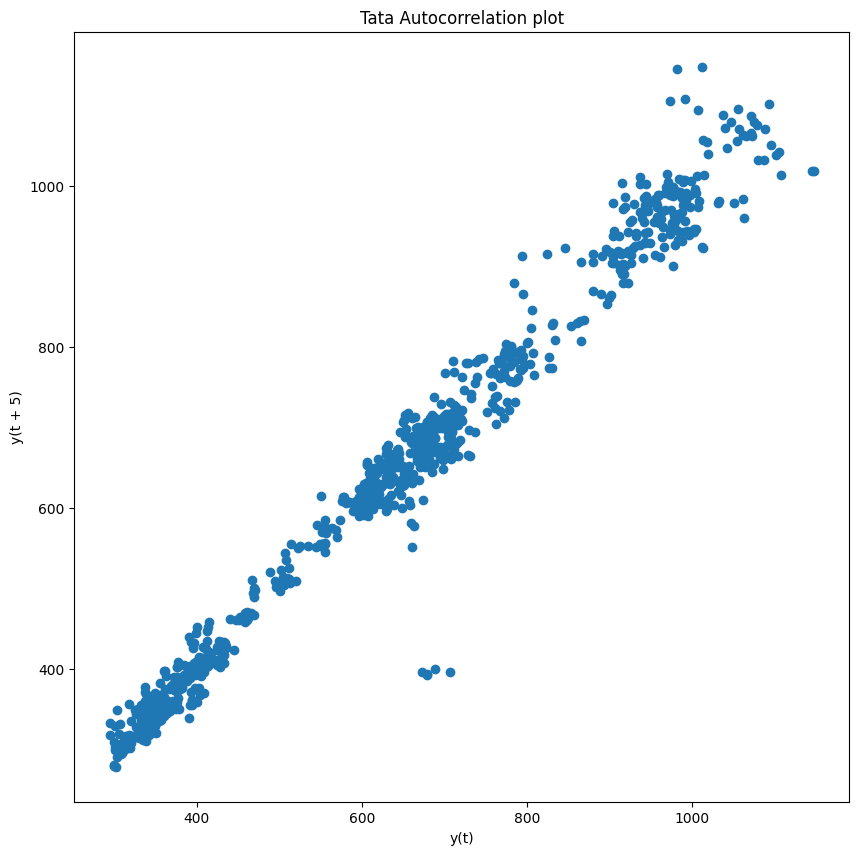

In [55]:
from pandas.plotting import lag_plot

plt.figure(figsize=(10, 10))
lag_plot(ttm['Open'], lag=5)
plt.title("Tata Autocorrelation plot")
plt.show()

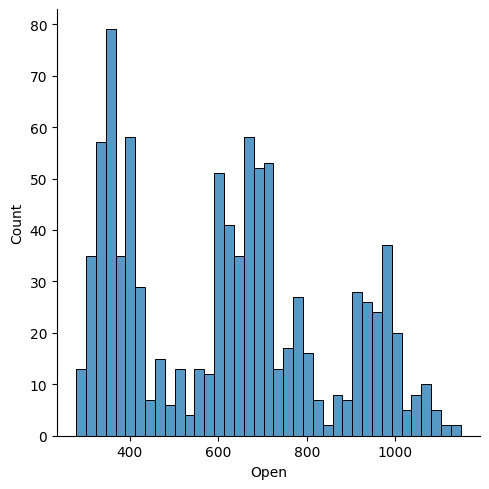

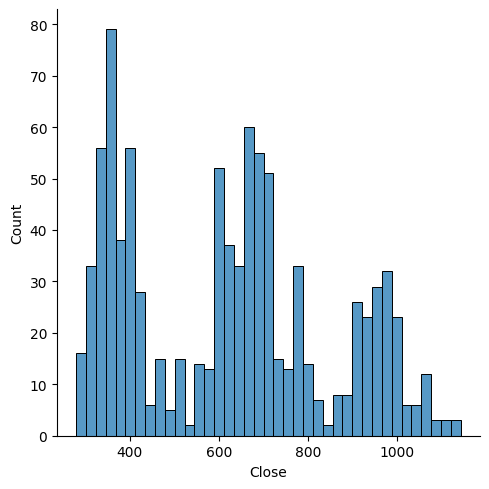

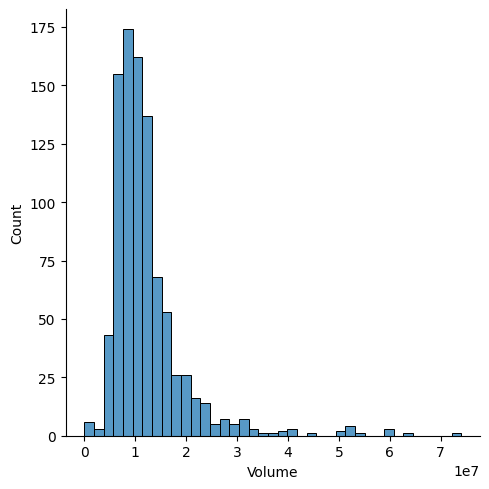

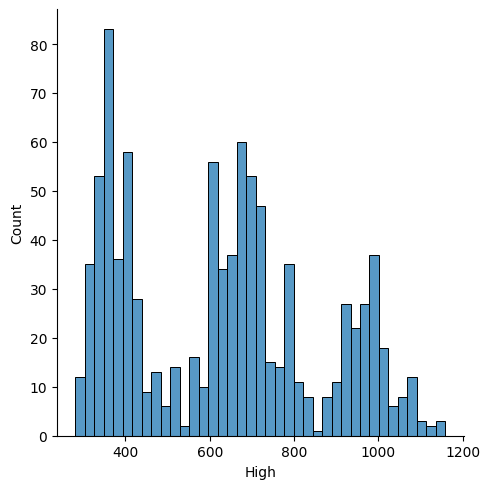

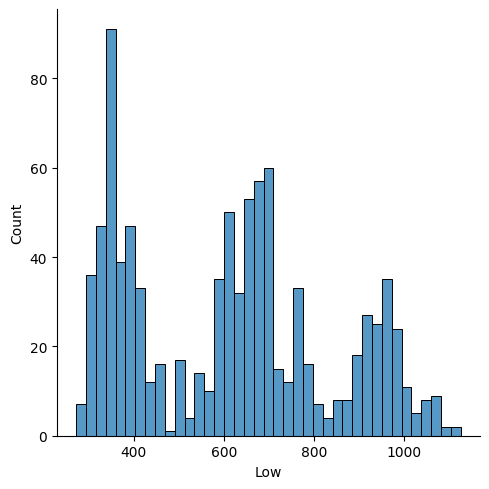

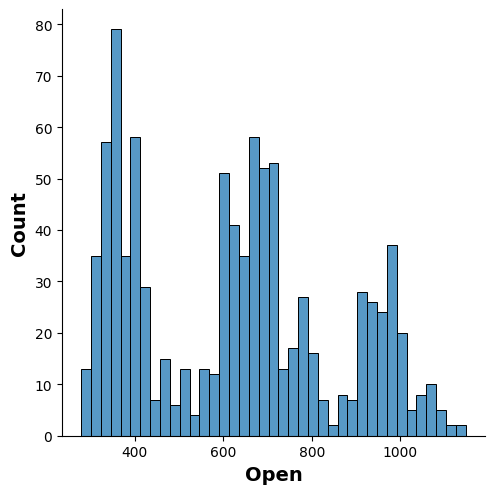

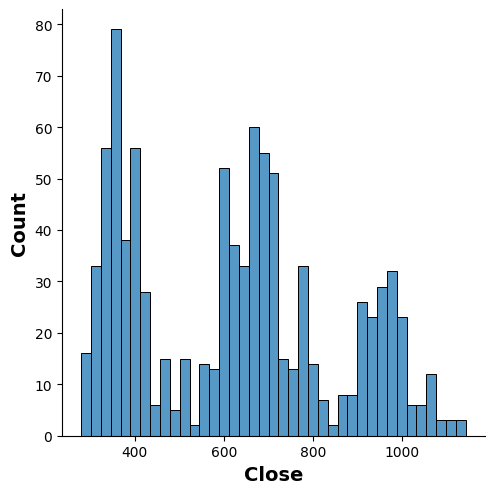

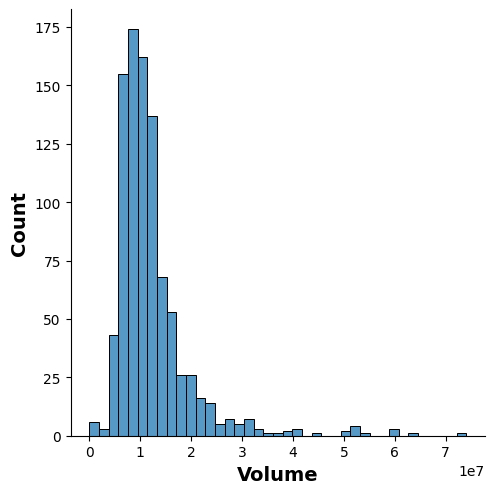

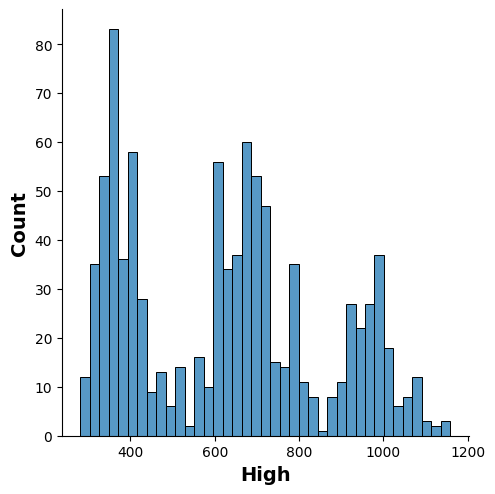

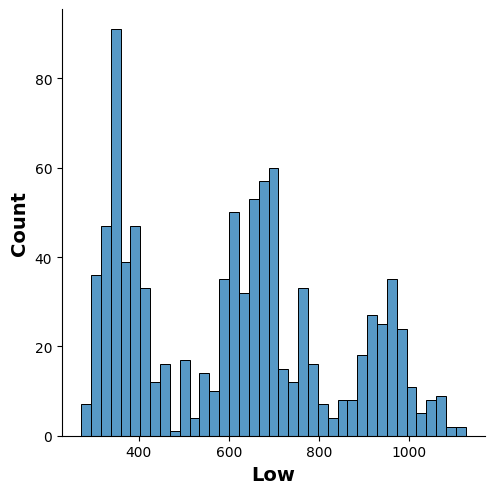

In [57]:
# Univariate analysis
sns.displot(ttm.Open.dropna(), kde=False, bins = 39);
sns.displot(ttm.Close.dropna(), kde=False, bins = 39);
sns.displot(ttm.Volume.dropna(), kde=False, bins = 39);
sns.displot(ttm.High.dropna(), kde=False, bins = 39);
sns.displot(ttm.Low.dropna(), kde=False, bins = 39);
for col in ['Open', 'Close', 'Volume', 'High', 'Low']:
    g = sns.displot(ttm[col].dropna(), kde=False, bins=39)
    g.set_axis_labels(col, 'Count', fontsize=14, fontweight='bold')
    plt.show()


# BIVARIATE ANALYSIS

## Pair plot

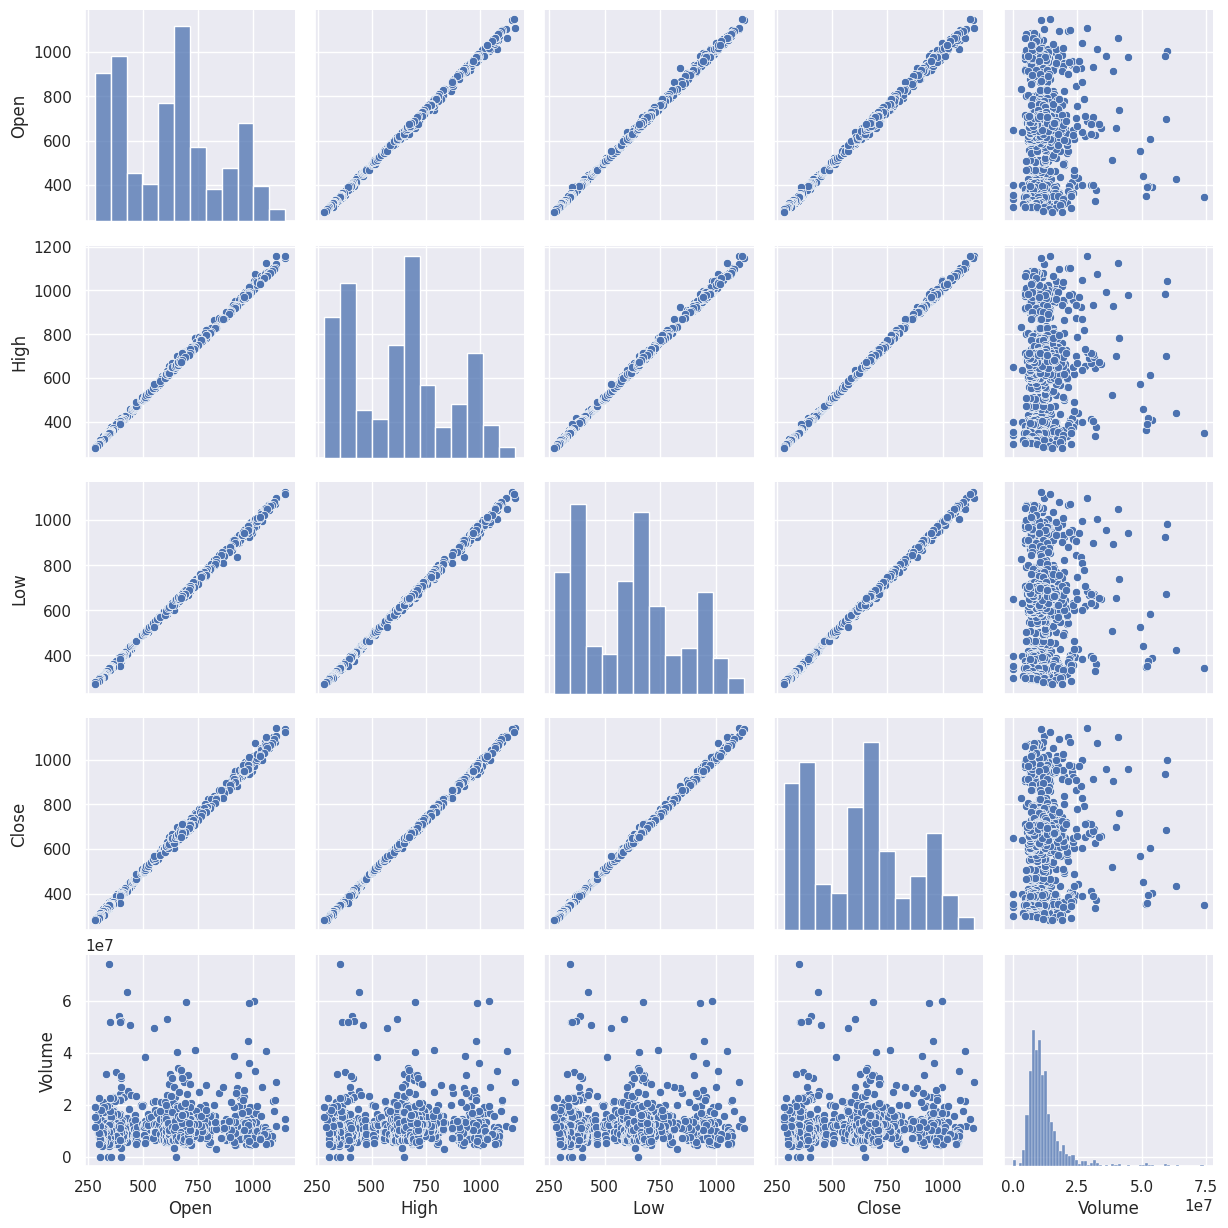

In [61]:
sns.pairplot(ttm[['Open', 'High', 'Low', 'Close', 'Volume']])

### Data Correlation

In [63]:
print(ttm.corr())

            Date     Close      High       Low      Open    Volume
Date    1.000000 -0.369639 -0.367502 -0.370469 -0.368163 -0.042971
Close  -0.369639  1.000000  0.999596  0.999531  0.998947  0.063962
High   -0.367502  0.999596  1.000000  0.999383  0.999490  0.073692
Low    -0.370469  0.999531  0.999383  1.000000  0.999437  0.051844
Open   -0.368163  0.998947  0.999490  0.999437  1.000000  0.061117
Volume -0.042971  0.063962  0.073692  0.051844  0.061117  1.000000


### Price prediction

In [64]:
!pip install autots
# Using the autots library in Python to prepare the stock prices of Tata Motors for the next 5 days

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 2.2 MB/s eta 0:00:00


In [ ]:
#from autots import AutoTS
#model = AutoTS(forecast_length=5, frequency='infer', ensemble='simple')
#model = model.fit(ttm, date_col='Date', value_col='Close', id_col=None)
#prediction = model.predict()
#forecast = prediction.forecast
#print(forecast)

# RANDOM FOREST REGRESSION

### Normalizing / scaling close value between 0 to 1

In [65]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, explained_variance_score, r2_score
from sklearn.metrics import mean_poisson_deviance, mean_gamma_deviance, accuracy_score
from sklearn.preprocessing import MinMaxScaler

In [66]:
# convert an array of values into a dataset matrix
def create_dataset(dataset, time_step=1):
    dataX, dataY = [], []
    for i in range(len(dataset) - time_step - 1):
        a = dataset[i:(i + time_step), 0]
        dataX.append(a)
        dataY.append(dataset[i + time_step, 0])
    return np.array(dataX), np.array(dataY)

### Split data for training and testing

In [72]:
def create_dataset(dataset, time_step=1):
    dataset = np.array(dataset)
    dataX, dataY = [], []
    for i in range(len(dataset) - time_step - 1):
        a = dataset[i:(i + time_step), 0]
        dataX.append(a)
        dataY.append(dataset[i + time_step, 0])
    return np.array(dataX), np.array(dataY)

training_size = int(len(closedf) * 0.65)
test_size = len(closedf) - training_size
train_data, test_data = closedf[0:training_size], closedf[training_size:]

print("train_Data: ", train_data.shape)
print("test_Data: ", test_data.shape)

time_step = 10
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

train_Data:  (84, 2)
test_Data:  (46, 2)
X_train shape: (73, 10)
X_test shape: (35, 10)


In [73]:
# convert an array of values into a dataset matrix
def create_dataset(dataset, time_step=1):
    dataX, dataY = [], []
    for i in range(len(dataset)-time_step-1):
        a = dataset[i:(i+time_step), 0]   ###i=0, 0,1,2,3-----99   100
        dataX.append(a)
        dataY.append(dataset[i + time_step, 0])
    return np.array(dataX), np.array(dataY)

In [77]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler(feature_range=(0, 1))
data_values = closedf[['Close']].values if hasattr(closedf, 'values') else np.array(closedf)
data_scaled = scaler.fit_transform(data_values)

training_size = int(len(data_scaled) * 0.65)
train_data = data_scaled[0:training_size]
test_data = data_scaled[training_size:]

X_train, y_train = create_dataset(train_data, time_step=10)
X_test, y_test = create_dataset(test_data, time_step=10)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("Model trained successfully.")


Model trained successfully.


In [80]:
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

print("Train predictions shape:", train_predict.shape)
print("Test predictions shape:", test_predict.shape)
print("First 5 test predictions:", test_predict[:5])

Train predictions shape: (73,)
Test predictions shape: (35,)
First 5 test predictions: [0.48527374 0.57127972 0.4704579  0.47216324 0.46324534]


# KNN

In [79]:
from sklearn import neighbors

K = time_step
neighbor = neighbors.KNeighborsRegressor(n_neighbors = K)
neighbor.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=10)

In [ ]:
# Lets Do the prediction

train_predict=neighbor.predict(X_train)
test_predict=neighbor.predict(X_test)

train_predict = train_predict.reshape(-1,1)
test_predict = test_predict.reshape(-1,1)

print("Train data prediction:", train_predict.shape)
print("Test data prediction:", test_predict.shape)

In [ ]:
# Transform back to original form

train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
original_ytrain = scaler.inverse_transform(y_train.reshape(-1,1))
original_ytest = scaler.inverse_transform(y_test.reshape(-1,1))

In [ ]:
import math

In [ ]:
# Evaluation metrices RMSE and MAE
print("Train data RMSE: ", math.sqrt(mean_squared_error(original_ytrain,train_predict)))
print("Train data MSE: ", mean_squared_error(original_ytrain,train_predict))
print("Test data MAE: ", mean_absolute_error(original_ytrain,train_predict))
print("-------------------------------------------------------------------------------------")
print("Test data RMSE: ", math.sqrt(mean_squared_error(original_ytest,test_predict)))
print("Test data MSE: ", mean_squared_error(original_ytest,test_predict))
print("Test data MAE: ", mean_absolute_error(original_ytest,test_predict))

#CONCLUSION

In [ ]:
#Explained variance regression score
#The explained variance score explains the dispersion of errors of a given dataset, and the formula is written as follows:
#Here, and Var(y) is the variance of prediction errors and actual values respectively. Scores close to 1.0 are highly desired,
 #indicating better squares of standard deviations of errors.

In [ ]:
print("Train data explained variance regression score:", explained_variance_score(original_ytrain, train_predict))
print("Test data explained variance regression score:", explained_variance_score(original_ytest, test_predict))

In [ ]:
# R2 score for regression
# R-squared (R2) is a statistical measure that represents the proportion of the
 # variance for a dependent variable that's explained by an independent variable or variables in a regression model.
 # 1 = Best
# 0 or < 0 = worse

print("Train data R2 score:", r2_score(original_ytrain, train_predict))
print("Test data R2 score:", r2_score(original_ytest, test_predict))

In [ ]:
x_input=test_data[len(test_data)-time_step:].reshape(1,-1)
temp_input=list(x_input)
temp_input=temp_input[0].tolist()

from numpy import array

lst_output=[]
n_steps=time_step
i=0
pred_days = 10
while(i<pred_days):

    if(len(temp_input)>time_step):

        x_input=np.array(temp_input[1:])
        #print("{} day input {}".format(i,x_input))
        x_input=x_input.reshape(1,-1)

        yhat = neighbor.predict(x_input)
        #print("{} day output {}".format(i,yhat))
        temp_input.extend(yhat.tolist())
        temp_input=temp_input[1:]

        lst_output.extend(yhat.tolist())
        i=i+1

    else:
        yhat = neighbor.predict(x_input)

        temp_input.extend(yhat.tolist())
        lst_output.extend(yhat.tolist())

        i=i+1

print("Output of predicted next days: ", len(lst_output))

### Plotting last 15 days and next predicted 10 days

In [ ]:
last_days=np.arange(1,time_step+1)
day_pred=np.arange(time_step+1,time_step+pred_days+1)
print(last_days)
print(day_pred)

In [ ]:
temp_mat = np.empty((len(last_days)+pred_days+1,1))
temp_mat[:] = np.nan
temp_mat = temp_mat.reshape(1,-1).tolist()[0]

last_original_days_value = temp_mat
next_predicted_days_value = temp_mat

last_original_days_value[0:time_step+1] = scaler.inverse_transform(closedf[len(closedf)-time_step:]).reshape(1,-1).tolist()[0]
next_predicted_days_value[time_step+1:] = scaler.inverse_transform(np.array(lst_output).reshape(-1,1)).reshape(1,-1).tolist()[0]

new_pred_plot = pd.DataFrame({
    'last_original_days_value':last_original_days_value,
    'next_predicted_days_value':next_predicted_days_value
})

names = cycle(['Last 15 days close price','Predicted next 10 days close price'])
fig = px.line(new_pred_plot,x=new_pred_plot.index, y=[new_pred_plot['last_original_days_value'],
                                                      new_pred_plot['next_predicted_days_value']],
              labels={'value': 'Stock price','index': 'Timestamp'})
fig.update_layout(title_text='Compare last 15 days vs next 10 days',
                  plot_bgcolor='white', font_size=15, font_color='black',legend_title_text='Close Price')
fig.for_each_trace(lambda t:  t.update(name = next(names)))

fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)
fig.show()

In [ ]:
knndf=closedf.tolist()
knndf.extend((np.array(lst_output).reshape(-1,1)).tolist())
knndf=scaler.inverse_transform(knndf).reshape(1,-1).tolist()[0]

names = cycle(['Close price'])

fig = px.line(knndf,labels={'value': 'Stock price','index': 'Timestamp'})
fig.update_layout(title_text='Plotting whole closing stock price with prediction',
                  plot_bgcolor='white', font_size=15, font_color='black',legend_title_text='Stock')
fig.for_each_trace(lambda t:  t.update(name = next(names)))

fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)
fig.show()